In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader
from src.data.synthetic_sofr_builder import build_term_sofr_curve

from src.term_structure.curve_merger import merge_curves
from src.term_structure.bootstrapping import (
    build_coupon_structure,
    bootstrap_dfs_from_sofr,
    bootstrap_dfs_from_treasury
)
from src.term_structure.curve_interpolator import log_linear_curve_interpolator
from src.term_structure.curve_builder import (
    build_zero_curve,
    build_forward_curve
)

from src.pricing.swap_pricing_engine import par_swap_curve

from src.hedging.hedge_instruments import (
    HedgeInstrument,
    HedgeUniverse
)
from src.hedging.hedge_ratio import HedgeRatio

from src.factors.yield_curve_pca import YieldCurvePCA
from src.factors.factor_risk import FactorRiskModel

from src.portfolio.swap_object import IRSwap
from src.portfolio.swap_portfolio import SwapPortfolio

from src.scenario.scenario_engine import ScenarioEngine


In [2]:
### Curve Builder
# downloading market curves
loader = MarketLoader()
curves = loader.loader_pipeline()

# building synthetic sofr curve from ON rates and futures
sofr_curve = build_term_sofr_curve(curves = curves)

# bootstrapping discount factors from sofr curve
df_sofr = bootstrap_dfs_from_sofr(
    sofr_curve = sofr_curve
)

# extracting treasury curve 
treasury_curve = curves['treasury']

# bootstrapping discount factors from treasury curve
df_treasury = bootstrap_dfs_from_treasury(
    treasury_curve = treasury_curve,
    short_dfs = df_sofr
)

# concatenating short-end and long-end into a single curve -> full curve
df_full_curve = merge_curves(
    short_curve = df_sofr,
    long_curve = df_treasury
)

# constructing semi-annual coupon structure
coupon_structure = build_coupon_structure(
    max_year = 30,
    freq = 2
)

# log-linear discount curve interpolation
df_loglinear_interp = log_linear_curve_interpolator(
    df_curve = df_full_curve,
    _target_times = coupon_structure
)

# building zero curve from log-linear discount curve
zero_curve_full = build_zero_curve(
    df_curve = df_loglinear_interp
)

# building forward curve from log-linear discount curve
forward_curve_full = build_forward_curve(
    df_curve = df_loglinear_interp
)

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..


In [3]:
### Sample Swap Portfolio 
# building swap portfolio
swap_list = [
    IRSwap(maturity = 4.0, fixed_rate = 0.0388, notional = 16_500_000, pay_receive = 'payer', freq = 2),
    IRSwap(maturity = 12.0, fixed_rate = 0.0442, notional = 22_750_000, pay_receive = 'receiver', freq = 2)
]

# creating swap portfolio instance
swap_portfolio = SwapPortfolio(swaps = swap_list)
swap_portfolio.summary()

,TradeID,Type,Maturity,FixedRate,Notional,CouponFrequency
0,0,payer,4.0,0.0388,16500000,2
1,1,receiver,12.0,0.0442,22750000,2


In [4]:
### Hedge Instruments
# extracting latest par swap curve
latest_par_swap_curve = par_swap_curve(
    df_curve = df_loglinear_interp,
    maturities= [2.0, 5.0, 10.0, 30.0],
    freq = 2
).iloc[-1]

# creating hedge instruments
hedges = [
    HedgeInstrument('HedgeSwap_2Y', 2.0, fixed_rate = float(latest_par_swap_curve.loc[2])),
    HedgeInstrument('HedgeSwap_5Y', 5.0, fixed_rate = float(latest_par_swap_curve.loc[5])),
    HedgeInstrument('HedgeSwap_10Y', 10.0, fixed_rate = float(latest_par_swap_curve.loc[10])),
    HedgeInstrument('HedgeSwap_30Y', 30.0, fixed_rate = float(latest_par_swap_curve.loc[30]))
]

# hedge universe
hedge_universe = HedgeUniverse(
    instruments = hedges
)

# building hedge swaps
hedge_swaps = hedge_universe.build_IRswaps()

display(hedge_universe.summary())

# creating hedge swap portfolio instance
hedgeSwaps_portfolio = SwapPortfolio(swaps = hedges)

,Instrument,Type,Maturity,Par Rate,Notional,CouponFreq
0,HedgeSwap_2Y,receiver,2.0,0.0378,1000000,2
1,HedgeSwap_5Y,receiver,5.0,0.0391,1000000,2
2,HedgeSwap_10Y,receiver,10.0,0.0430,1000000,2
3,HedgeSwap_30Y,receiver,30.0,0.0489,1000000,2


In [5]:
# defining key-rate tenors
keyrate_tenors = [2.0, 5.0, 10.0, 30.0]

# portfolio dv01 - key_rate
portfolio_keyrate_dv01 = swap_portfolio.portfolio_dv01(
    df_curve = df_loglinear_interp,
    shock_type = 'key_rate',
    key_rate_tenors = keyrate_tenors
).iloc[-1]

print('--- Portfolio DV01 (Key-Rate) --')
print(portfolio_keyrate_dv01)
print()

# hedge portfolio dv01 - key_rate
hedge_portfolio_keyrate_dv01 = hedgeSwaps_portfolio.portfolio_dv01(
    df_curve = df_loglinear_interp,
    shock_type = 'key_rate',
    key_rate_tenors = keyrate_tenors
).iloc[-1]

print('--- Hedge Portfolio DV01 (Key-Rate) --')
print(hedge_portfolio_keyrate_dv01)

--- Portfolio DV01 (Key-Rate) --
Portfolio_DV01_2Y     152.7
Portfolio_DV01_5Y     207.0
Portfolio_DV01_10Y    326.8
Portfolio_DV01_30Y      0.0
Name: 2026-04-21 00:00:00, dtype: float64

--- Hedge Portfolio DV01 (Key-Rate) --
Portfolio_DV01_2Y     201.1
Portfolio_DV01_5Y     438.8
Portfolio_DV01_10Y    679.8
Portfolio_DV01_30Y    673.8
Name: 2026-04-21 00:00:00, dtype: float64


In [6]:
### PCA Yield Curve Model
# building PCA model for yield curve risk factors
pca_model = YieldCurvePCA(n_factors = 3)

# fitting PCA model
pca_model.fit(zero_curve = zero_curve_full, key_rate_tenors = keyrate_tenors)     # type: ignore

# explained variance
display(pca_model.explained_variance())

# factor loadings
factor_loadings = pca_model.get_factor_loadings()
factor_loadings

,EigenValue,Explained_Variance,Cumulative_Explained
Factor_0,1.038373e-06,0.847016,0.847016
Factor_1,1.654544e-07,0.134964,0.981980
Factor_2,2.209103e-08,0.018020,1.000000


,Factor_0,Factor_1,Factor_2
2.0,-0.482437,-0.641494,-0.577586
5.0,-0.552527,-0.221153,0.558221
10.0,-0.520904,0.249666,0.348001
30.0,-0.436608,0.690828,-0.483404


In [7]:
### Factor Risk Model
# creating factor risk model instance
factor_risk_model = FactorRiskModel(pca_model = pca_model)

# portfolio factor exposures
portfolio_factor_exposure = factor_risk_model.tenor_to_factor_exposure(
    dv01_vector = portfolio_keyrate_dv01
)

print(portfolio_factor_exposure)

# hedge factor exposures - computing each hedge individually
hedge_factor_exposures = {}

for hedge in hedge_swaps:
    
    hedge_port = SwapPortfolio(swaps = [hedge])

    dv01 = hedge_port.portfolio_dv01(
        df_curve = df_loglinear_interp,
        shock_type = 'key_rate',
        key_rate_tenors = [2.0, 5.0, 10.0, 30.0]
    ).iloc[-1]

    hedge_factor_exposures[hedge.maturity] = factor_risk_model.tenor_to_factor_exposure(
        dv01_vector = dv01
    )

hedge_factor_exposures_df = pd.DataFrame.from_dict(hedge_factor_exposures)

# build hedge factor matrix
hedge_factor_matrix = hedge_factor_exposures_df.T
hedge_factor_matrix

Factor_0   -358.272774
Factor_1    -62.143912
Factor_2    141.080925
dtype: float64


,Factor_0,Factor_1,Factor_2
2.0,-91.180625,-121.242288,-109.163755
5.0,-233.687702,-95.149607,232.261846
10.0,-352.675519,161.219180,233.695370
30.0,-310.220605,464.329499,-317.145501


In [8]:
# solve for optimal hedge notionals
hedge_notionals = HedgeRatio.solve_hedge_notionals(
    portfolio_factor_exposure = portfolio_factor_exposure.values,
    hedge_factor_matrix = hedge_factor_matrix.values
)

print('Optimal hedge notionals:', hedge_notionals)

# residual risk after hedging
residual_exposure = HedgeRatio.residual_factor_exposure(
    portfolio_factor_exposure = portfolio_factor_exposure.values,
    hedge_factor_matrix = hedge_factor_matrix.values,
    hedge_notionals = hedge_notionals
)

print('Redisudal factor exposure after hedging:', residual_exposure)

# summary hedge report
hedge_names = hedge_universe.summary()['Instrument']

hedge_df, exposure_df = HedgeRatio.hedge_report(
    hedge_names = hedge_names,
    hedge_notionals = hedge_notionals,
    portfolio_factor_exposure = portfolio_factor_exposure,
    residual_exposure = residual_exposure
)

display(hedge_df)
display(exposure_df)

Optimal hedge notionals: [-0.68678083 -0.65883692 -0.34982675 -0.05903622]
Redisudal factor exposure after hedging: [ 5.68434189e-14 -1.56319402e-13  1.42108547e-13]


,HedgeInstrument,Type,Notional,TradeNotional_USD
0,HedgeSwap_2Y,payer,-0.686781,-686.8k
1,HedgeSwap_5Y,payer,-0.658837,-658.8k
2,HedgeSwap_10Y,payer,-0.349827,-349.8k
3,HedgeSwap_30Y,payer,-0.059036,-59.0k


,PortfolioExposure,ResidualExposure
Factor_0,-358.272774,5.684342e-14
Factor_1,-62.143912,-1.563194e-13
Factor_2,141.080925,1.421085e-13


In [9]:
### Hedged Portfolio
# converting optimal hedge trades into IRSwaps
hedge_trades = []

for swap, w in zip(hedge_swaps, hedge_notionals):
    hedge_trades.append(
        IRSwap(
            maturity = swap.maturity,
            fixed_rate = swap.fixed_rate,
            notional = w * 1_000_000,       # converting hedge multiplier into trade notional USD
            pay_receive = 'payer' if w < 0 else 'receiver',
            freq = 2
        )
    )

# combine portfolios
hedged_portfolio = SwapPortfolio(
    swaps = swap_list + hedge_trades
)

hedged_portfolio.summary()

,TradeID,Type,Maturity,FixedRate,Notional,CouponFrequency
0,0,payer,4.0,0.0388,1.650000e+07,2
1,1,receiver,12.0,0.0442,2.275000e+07,2
2,2,payer,2.0,0.0378,-6.867808e+05,2
3,3,payer,5.0,0.0391,-6.588369e+05,2
4,4,payer,10.0,0.0430,-3.498268e+05,2
5,5,payer,30.0,0.0489,-5.903622e+04,2


In [10]:
# computing key-rate portfolio DV01 - Post-Hedge
hedged_keyrate_portfolio_dv01 = hedged_portfolio.portfolio_dv01(
    df_curve = df_loglinear_interp,
    shock_type = 'key_rate',
    key_rate_tenors = [2.0, 5.0, 10.0, 30.0]
).iloc[-1]

display(
    pd.DataFrame({
        'Pre-Hedge': portfolio_keyrate_dv01,
        'Post_Hedge': hedged_keyrate_portfolio_dv01
    })
)

,Pre-Hedge,Post_Hedge
Portfolio_DV01_2Y,152.7,18.8
Portfolio_DV01_5Y,207.0,-73.3
Portfolio_DV01_10Y,326.8,93.6
Portfolio_DV01_30Y,0.0,-39.8


In [11]:
# computing factor exposure - Post-Hedge
hedged_factor_exposure = factor_risk_model.tenor_to_factor_exposure(
    dv01_vector = hedged_keyrate_portfolio_dv01
)

display(
    pd.DataFrame({
        'Pre_Hedge': portfolio_factor_exposure,
        'Post_Hedge': hedged_factor_exposure
    })
)

,Pre_Hedge,Post_Hedge
Factor_0,-358.272774,0.050810
Factor_1,-62.143912,0.024261
Factor_2,141.080925,0.036115


In [12]:
# extracting historical factor returns
factor_returns = pca_model.get_factor_returns()
factor_returns = factor_returns.copy() # type: ignore

print('Factor return matrix shape:', factor_returns.shape)
factor_returns.tail()

Factor return matrix shape: (2100, 3)


,Factor_0,Factor_1,Factor_2
2026-04-15,-0.000391,0.000125,0.000195
2026-04-16,-0.000505,0.000245,-0.000172
2026-04-17,0.001243,0.000118,0.000045
2026-04-20,-0.000127,-0.000121,0.000056
2026-04-21,-0.000738,-0.000403,0.000071


In [13]:
### Scenario Engine Stress Testing
# create scenario engine instance
scenario_engine = ScenarioEngine(
    factor_risk_model = factor_risk_model
)

### generating scenario factor moves
# historical worst-case scenario generator
Z_hist = scenario_engine.historical_scenarios(n_scenarios = 200)
display(Z_hist.head())

# Monte Carlo scenario generator
Z_mc = scenario_engine.monte_carlo_scenarios(n_scenarios = 20000)
display(Z_mc.head())

# user-defined custom scenario shock generator
Z_custom = scenario_engine.custom_scenarios(
    parallel_shock_bps = +100,
    short_rate_bps = +150,
    steepener_bps = +70,
    flattener_bps = +70
)
display(Z_custom.head())

,Factor_0,Factor_1,Factor_2
0,-0.001361,-0.001111,0.000390
1,-0.001732,-0.000483,0.000095
2,0.001770,0.000153,-0.000291
3,-0.001784,-0.000268,0.000071
4,-0.001770,0.000366,0.000068


,Factor_0,Factor_1,Factor_2
0,-1.722656e-03,0.000190,4.878078e-06
1,-4.152616e-04,0.000321,3.070072e-07
2,9.073086e-07,0.000714,1.512550e-04
3,-6.119117e-04,0.000254,-2.549731e-05
4,-5.149032e-04,0.000106,-3.607992e-05


,Factor_0,Factor_1,Factor_2
Parallel Up,-0.019925,0.000778,-0.001548
Parallel Down,0.019925,-0.000778,0.001548
Short Up,-0.016334,-0.009802,-0.001407
Short Down,0.016334,0.009802,0.001407
Steepener,0.000352,0.009797,0.000449


In [14]:
### Scenario Pnl Distributions
# historical worst-case scenario 
pnl_hist_pre = scenario_engine.scenario_pnl(
    factor_scenarios = Z_hist,
    factor_exposure = portfolio_factor_exposure 
)
pnl_hist_post = scenario_engine.scenario_pnl(
    factor_scenarios = Z_hist,
    factor_exposure = hedged_factor_exposure 
)

# Monte Carlo scenario
pnl_mc_pre = scenario_engine.scenario_pnl(
    factor_scenarios = Z_mc,
    factor_exposure = portfolio_factor_exposure
)
pnl_mc_post = scenario_engine.scenario_pnl(
    factor_scenarios = Z_mc,
    factor_exposure = hedged_factor_exposure
)

# custom scenario
pnl_custom_pre = scenario_engine.scenario_pnl(
    factor_scenarios = Z_custom,
    factor_exposure = portfolio_factor_exposure
)
pnl_custom_post = scenario_engine.scenario_pnl(
    factor_scenarios = Z_custom,
    factor_exposure = hedged_factor_exposure
)

In [15]:
### Scenario Report - VaR, CVaR & Worst Loss
#historical worst-case scenario 
report_hist_pre = scenario_engine.scenario_risk_metrics(scenario_pnl = pnl_hist_pre, confidence = 0.99)
report_hist_post = scenario_engine.scenario_risk_metrics(scenario_pnl = pnl_hist_post, confidence = 0.99)

#Monte Carlo scenario
report_mc_pre = scenario_engine.scenario_risk_metrics(scenario_pnl = pnl_mc_pre, confidence = 0.99)
report_mc_post = scenario_engine.scenario_risk_metrics(scenario_pnl = pnl_mc_post, confidence = 0.99)

# custom scenario
report_custom_pre = scenario_engine.scenario_risk_metrics(scenario_pnl = pnl_custom_pre, confidence = 0.99)
report_custom_post = scenario_engine.scenario_risk_metrics(scenario_pnl = pnl_custom_post, confidence = 0.99)

results = {
    'Historical Pre-Hedge': report_hist_pre,
    'Historical Post-Hedge': report_hist_post,
    'MonteCarlo Pre-Hedge': report_mc_pre,
    'MonteCarlo Post-Hedge': report_mc_post,
    'Custom Pre-Hedge': report_custom_pre,
    'Custom Post-Hedge': report_custom_post
}

display(pd.DataFrame(results))

,Historical Pre-Hedge,Historical Post-Hedge,MonteCarlo Pre-Hedge,MonteCarlo Post-Hedge,Custom Pre-Hedge,Custom Post-Hedge
Scenario VaR:,-1.419301,-0.000268,-0.851895,-0.000123,-6.841328,-0.001115
Scenario CVaR,-1.671181,-0.000313,-0.975025,-0.000140,-6.871776,-0.001119
Worst Loss,-2.036885,-0.000313,-1.418630,-0.000244,-6.871776,-0.001119


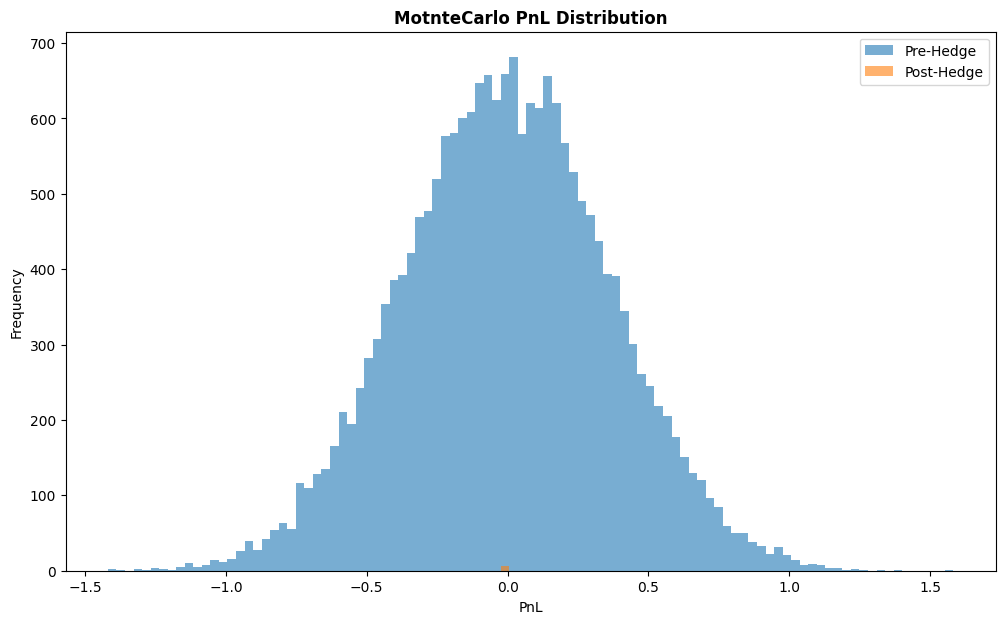

In [16]:
# Monte Carlo Distribution Plot
plt.figure(figsize = (12, 7))

# common bins
mc_data = np.concatenate([pnl_mc_pre, pnl_mc_post])
mc_bins = np.linspace(mc_data.min(), mc_data.max(), 100)

plt.hist(pnl_mc_pre, bins = mc_bins, alpha = 0.6, label = 'Pre-Hedge')
plt.hist(pnl_custom_post, bins = mc_bins, alpha = 0.6, label = 'Post-Hedge')

plt.title('MotnteCarlo PnL Distribution', fontweight = 'bold')
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.legend(loc = 'best')
plt.show()